# XGBoost challenger

Gradient-boosted tree model on the same panel, features, and outcome as the dynamic logit, for a like-for-like comparison. Hyperparameters are tuned by AUC-PR over a time-series split; raw probabilities are Platt-scaled (sigmoid) before any probability-level use.

**Notes for validation**
- **Class imbalance:** `scale_pos_weight` = negatives/positives in the training sample.
- **Tuning:** `RandomizedSearchCV` over a `TimeSeriesSplit` (train on past, validate on future) — no random folds.
- **Calibration:** a sigmoid is fit on the frozen booster; ranking metrics (AUC/KS) use raw scores, while calibration ratios and expected loss use the calibrated probabilities.
- Input: `intermediate/panel_clean.csv`. Figures → `figures/`; prediction/summary CSVs → `intermediate/`.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy.stats import ks_2samp
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    make_scorer,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

## Configuration

Keep `DATA_DIR` consistent with `clean_data.ipynb` / `dynamic_logit.ipynb`.

In [2]:
# DATA_DIR must contain intermediate/panel_clean.csv (written by clean_data.ipynb).
# Default assumes the repo layout (notebooks/ and data/ are siblings). Override with:
#     export DATA_DIR=/absolute/path/to/your/Credit_risk/Data
DATA_DIR = Path(os.environ.get("DATA_DIR", "../data"))
INTERIM = DATA_DIR / "intermediate"
 
# figures/ lives at the repo root, one level up from notebooks/
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
 
# Fail early if the panel is missing. Raising rather than printing keeps local
# absolute paths out of committed notebook output.
if not (INTERIM / "panel_clean.csv").exists():
    raise FileNotFoundError(
        "panel_clean.csv not found under DATA_DIR/intermediate. Run clean_data.ipynb "
        "first, or set DATA_DIR, e.g. export DATA_DIR=/path/to/Data"
    )

## 1. Load panel and out-of-time splits

Identical panel and splits to `dynamic_logit.ipynb` for a direct comparison.

In [3]:
df = pd.read_csv(INTERIM / "panel_clean.csv")
 
features = [
    "leverage", "int_coverage", "roa", "current_ratio", "cash_ratio", "log_at",
    "nimta", "tlmta", "cashmta", "price", "trail_12m_ret", "eq_vol", "mtb",
]
outcome = "default_flag"
 
FEATURE_LABELS = {
    "leverage": "Book leverage", "int_coverage": "Interest coverage", "roa": "ROA",
    "current_ratio": "Current ratio", "cash_ratio": "Cash/assets", "log_at": "Log assets",
    "nimta": "NIMTA", "tlmta": "TLMTA", "cashmta": "CASHMTA", "price": "Log price",
    "trail_12m_ret": "Trailing 12-month return", "eq_vol": "Equity volatility", "mtb": "Market-to-book",
}
 
train = df[df["fyear"] <= 2005].copy()
test_sets = {
    "test1": df[df["fyear"].between(2006, 2010)],
    "test2": df[df["fyear"].between(2011, 2015)],
    "test3": df[df["fyear"] > 2015],
}
 
for label, data in {"train": train, **test_sets}.items():
    n, tot = int(data[outcome].sum()), len(data)
    print(f"{label}: {n} defaults / {tot:,} firm-years ({n / tot * 100:.3f}%)")

train: 1448 defaults / 103,154 firm-years (1.404%)
test1: 197 defaults / 17,298 firm-years (1.139%)
test2: 121 defaults / 15,475 firm-years (0.782%)
test3: 104 defaults / 21,629 firm-years (0.481%)


## 2. Hyperparameter tuning (time-series CV)

`scale_pos_weight` corrects the class imbalance; `RandomizedSearchCV` evaluates 50 configurations over 5 expanding time-series folds (250 fits), scored by AUC-PR.

In [4]:
neg = int((train[outcome] == 0).sum())
pos = int((train[outcome] == 1).sum())
spw = neg / pos
print(f"scale_pos_weight: {spw:.2f}  (neg/pos = {neg:,}/{pos:,})")

tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    "n_estimators":     [200, 300, 500, 700],
    "max_depth":        [2, 3, 4, 5],
    "learning_rate":    [0.01, 0.05, 0.1],
    "subsample":        [0.6, 0.7, 0.8],
    "colsample_bytree": [0.6, 0.7, 0.8],
    "min_child_weight": [1, 5, 10, 20],
    "reg_lambda":       [1, 5, 10],
}

scorer = make_scorer(average_precision_score, response_method="predict_proba")

base_model = xgb.XGBClassifier(
    scale_pos_weight=spw, eval_metric="aucpr", random_state=42, n_jobs=-1
)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=50,
    cv=tscv,
    scoring=scorer,
    refit=False,        # refit manually on the full training set below
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
search.fit(train[features], train[outcome])

scale_pos_weight: 70.24  (neg/pos = 101,706/1,448)
Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.7, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'min_child_weight': [1, 5, ...], ...}"
,n_iter,50
,scoring,make_scorer(a...redict_proba')
,n_jobs,-1
,refit,False
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


### Top configurations

In [5]:
cv_results = pd.DataFrame(search.cv_results_)
param_cols = [c for c in cv_results.columns if c.startswith("param_")]
summary = cv_results[param_cols + ["mean_test_score", "std_test_score"]].copy()
summary.columns = [c.replace("param_", "") for c in summary.columns]
summary = summary.sort_values("mean_test_score", ascending=False)

print("Top 10 combinations:")
print(summary.head(10).to_string(index=False))
print(f"\nBest AUC-PR: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Top 10 combinations:
 subsample  reg_lambda  n_estimators  min_child_weight  max_depth  learning_rate  colsample_bytree  mean_test_score  std_test_score
       0.6          10           300                10          2           0.05               0.7         0.170074        0.048883
       0.6           5           500                20          2           0.05               0.7         0.168845        0.049755
       0.6           1           200                20          3           0.05               0.7         0.168518        0.052654
       0.7          10           700                 5          2           0.05               0.6         0.168323        0.050761
       0.6          10           500                 1          2           0.05               0.6         0.168183        0.048262
       0.8           1           200                20          3           0.05               0.7         0.167321        0.050359
       0.7           5           300                10 

### Hyperparameter sensitivity (diagnostic)

Mean AUC-PR by value for each hyperparameter — shows which settings matter. Not a paper figure, but useful for the repo.

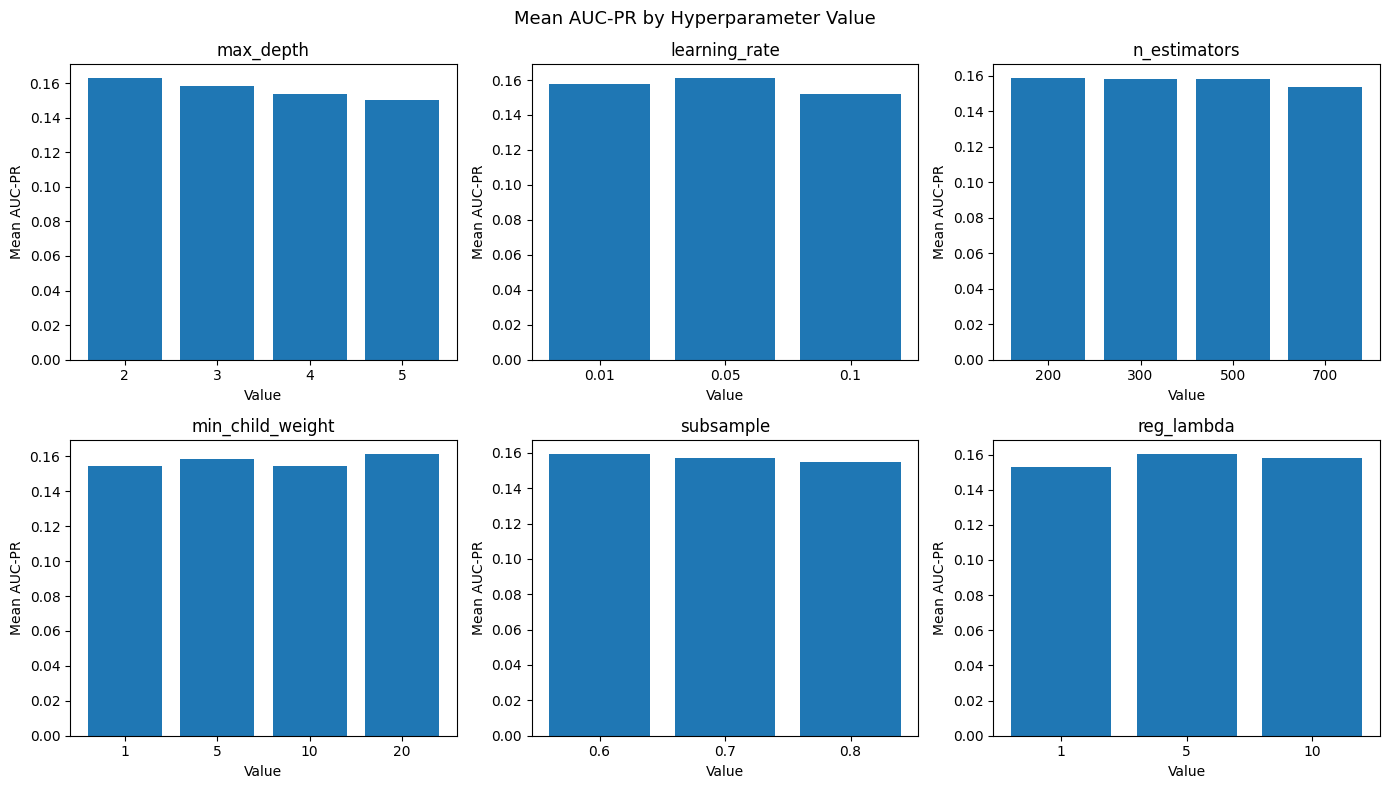

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
key_params = ["param_max_depth", "param_learning_rate", "param_n_estimators",
              "param_min_child_weight", "param_subsample", "param_reg_lambda"]
for ax, param in zip(axes.flat, key_params):
    grouped = cv_results.groupby(param)["mean_test_score"].mean()
    ax.bar([str(k) for k in grouped.index], grouped.values)
    ax.set_title(param.replace("param_", ""))
    ax.set_xlabel("Value")
    ax.set_ylabel("Mean AUC-PR")
plt.suptitle("Mean AUC-PR by Hyperparameter Value", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "xgb_cv_param_sensitivity.png", dpi=150)
plt.show()

## 3. Refit on the full training set with the best parameters

In [7]:
best_params = search.best_params_
print("Best params:", best_params)

model_xgb = xgb.XGBClassifier(
    **best_params, scale_pos_weight=spw, eval_metric="aucpr", random_state=42, n_jobs=-1
)
model_xgb.fit(train[features], train[outcome])

Best params: {'subsample': 0.6, 'reg_lambda': 10, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


## 4. Out-of-sample discrimination

AUC-ROC, AUC-PR, and KS, on raw scores (Platt scaling is monotone, so it does not change ranking metrics).

In [8]:
def evaluate(model, test_df, label):
    X = test_df[features]
    y = test_df[outcome]
    pred = model.predict_proba(X)[:, 1]
    ks, _ = ks_2samp(pred[y == 1], pred[y == 0])
    return {
        "label": label,
        "auc_roc": roc_auc_score(y, pred),
        "auc_pr": average_precision_score(y, pred),
        "ks": ks,
    }


pd.DataFrame([evaluate(model_xgb, d, lbl) for lbl, d in test_sets.items()]).set_index("label").round(4)

,auc_roc,auc_pr,ks
label,,,
test1,0.9268,0.2076,0.7333
test2,0.9295,0.1481,0.7302
test3,0.9163,0.0567,0.7231


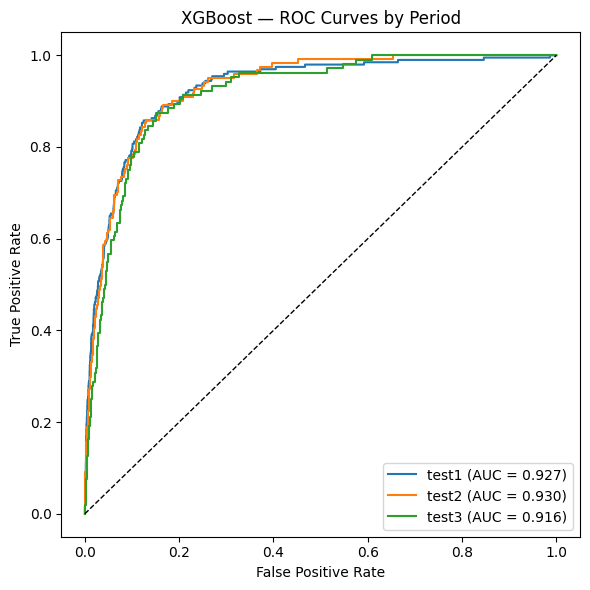

In [9]:
plt.figure(figsize=(6, 6))
for label, test_df in test_sets.items():
    y = test_df[outcome]
    pred = model_xgb.predict_proba(test_df[features])[:, 1]
    fpr, tpr, _ = roc_curve(y, pred)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc_score(y, pred):.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost — ROC Curves by Period")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "xgb_roc_curves.png", dpi=150)
plt.show()

## 5. Probability calibration (Platt scaling)

A sigmoid is fit on the frozen booster to map class-weighted scores back to realistic probabilities, without changing rankings.

In [10]:
calibrated = CalibratedClassifierCV(FrozenEstimator(model_xgb), method="sigmoid")
calibrated.fit(train[features], train[outcome])

,estimator,"FrozenEstimat...ee=None, ...))"
,method,'sigmoid'
,cv,None
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [11]:
rows = []
for label, test_df in test_sets.items():
    pred = calibrated.predict_proba(test_df[features])[:, 1]
    rows.append({
        "period": label,
        "avg_predicted_PD": pred.mean(),
        "actual_default_rate": test_df[outcome].mean(),
    })
cal = pd.DataFrame(rows).set_index("period")
cal["ratio"] = cal["avg_predicted_PD"] / cal["actual_default_rate"]
print(cal.round(4))

        avg_predicted_PD  actual_default_rate   ratio
period                                               
test1             0.0084               0.0114  0.7396
test2             0.0070               0.0078  0.8897
test3             0.0100               0.0048  2.0732


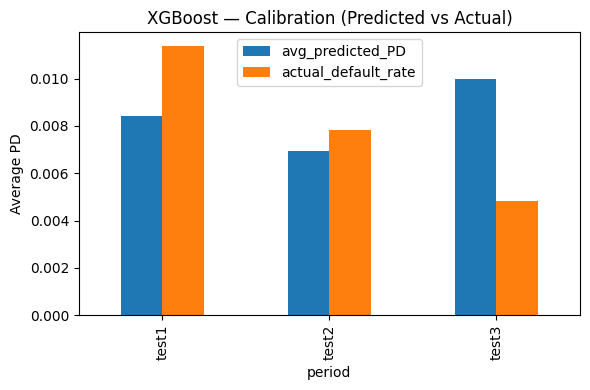

In [12]:
ax = cal.plot(kind="bar", y=["avg_predicted_PD", "actual_default_rate"], figsize=(6, 4))
ax.set_ylabel("Average PD")
ax.set_title("XGBoost — Calibration (Predicted vs Actual)")
plt.tight_layout()
plt.savefig(FIG_DIR / "xgb_calibration.png", dpi=150)
plt.show()

### Save calibrated predictions

Per-firm calibrated PDs with `fyear` and EAD, for the cross-model comparison.

In [13]:
pred_rows = []
for label, test_df in test_sets.items():
    pred = calibrated.predict_proba(test_df[features])[:, 1]
    pred_rows.append(pd.DataFrame({
        "period": label,
        "fyear": test_df["fyear"].values,
        "y_true": test_df[outcome].values,
        "pred_proba": pred,
        "EAD": (test_df["dltt"] + test_df["dlc"]).values,
    }))
xgb_preds = pd.concat(pred_rows, ignore_index=True)
xgb_preds.to_csv(INTERIM / "xgb_predictions.csv", index=False)
print(f"Saved {len(xgb_preds):,} predictions to intermediate/xgb_predictions.csv")

Saved 54,402 predictions to intermediate/xgb_predictions.csv


## 6. Goodness of fit — pseudo-\(R^2\)

Computed on the **calibrated** model (raw class-weighted probabilities give nonsensical, large-negative values). Out-of-sample null is anchored to the training base rate.

In [14]:
def pseudo_r2(model, data, train_base_rate):
    """McFadden pseudo-R^2 from binary cross-entropy; null = training base rate."""
    y = data[outcome].values
    pred = np.clip(model.predict_proba(data[features])[:, 1], 1e-10, 1 - 1e-10)
    llf = np.sum(y * np.log(pred) + (1 - y) * np.log(1 - pred))
    p0 = train_base_rate
    ll0 = np.sum(y * np.log(p0) + (1 - y) * np.log(1 - p0))
    return 1 - llf / ll0
 
 
train_base_rate = train[outcome].mean()
 
# In-sample metrics are computed on the TRAINING set
print(f"In-sample pseudo-R^2:  {pseudo_r2(calibrated, train, train_base_rate):.4f}")
print("Campbell (2008) ref.:  0.3120\n")
 
oos = pd.DataFrame(
    [{"period": lbl, "pseudo_r2": pseudo_r2(calibrated, d, train_base_rate)} for lbl, d in test_sets.items()]
).set_index("period")
print("Out-of-sample pseudo-R^2:")
print(oos.round(4))

In-sample pseudo-R^2:  0.3277
Campbell (2008) ref.:  0.3120

Out-of-sample pseudo-R^2:
        pseudo_r2
period           
test1      0.3067
test2      0.3060
test3      0.2758


### Save summary metrics

In [15]:
summary_rows = []
for label, test_df in test_sets.items():
    perf = evaluate(calibrated, test_df, label)
    pred = calibrated.predict_proba(test_df[features])[:, 1]
    summary_rows.append({
        "model": "xgboost", "period": label,
        "auc_roc": perf["auc_roc"], "auc_pr": perf["auc_pr"], "ks": perf["ks"],
        "pseudo_r2": pseudo_r2(calibrated, test_df, train_base_rate),
        "calibration_ratio": pred.mean() / test_df[outcome].mean(),
    })

# In-sample row — all computed on the TRAINING set
in_perf = evaluate(calibrated, train, "in_sample")
in_pred = calibrated.predict_proba(train[features])[:, 1]
summary_rows.append({
    "model": "xgboost", "period": "in_sample",
    "auc_roc": in_perf["auc_roc"], "auc_pr": in_perf["auc_pr"], "ks": in_perf["ks"],
    "pseudo_r2": pseudo_r2(calibrated, train, train_base_rate),
    "calibration_ratio": in_pred.mean() / train[outcome].mean(),
})

xgb_summary = pd.DataFrame(summary_rows)
xgb_summary.to_csv(INTERIM / "xgb_summary.csv", index=False)
xgb_summary

,model,period,auc_roc,auc_pr,ks,pseudo_r2,calibration_ratio
0,xgboost,test1,0.926822,0.207583,0.733255,0.306726,0.739632
1,xgboost,test2,0.929504,0.148111,0.730157,0.305964,0.889697
2,xgboost,test3,0.916349,0.056693,0.723130,0.275799,2.073185
3,xgboost,in_sample,0.937324,0.189661,0.740492,0.327725,1.000049


## 7. Expected loss

\(EL = PD \times EAD \times LGD\) on the calibrated PDs (LGD = 45%), reported as annual averages within each window.

In [16]:
LGD = 0.45
for label, test_df in test_sets.items():
    t = test_df.copy()
    t["EAD"] = t["dltt"] + t["dlc"]
    t["PD"] = calibrated.predict_proba(t[features])[:, 1]
    t["EL"] = t["PD"] * t["EAD"] * LGD
    annual = t.groupby("fyear")[["EAD", "EL"]].sum()
    avg_EAD, avg_EL = annual["EAD"].mean(), annual["EL"].mean()
    print(f"{label}  |  Avg Annual EAD: ${avg_EAD / 1e3:,.1f}B  |  "
          f"Avg Annual EL: ${avg_EL / 1e3:,.1f}B  |  EL/EAD: {avg_EL / avg_EAD * 100:.2f}%  |  "
          f"Avg PD: {t['PD'].mean() * 100:.2f}%")

test1  |  Avg Annual EAD: $4,065.5B  |  Avg Annual EL: $6.8B  |  EL/EAD: 0.17%  |  Avg PD: 0.84%
test2  |  Avg Annual EAD: $5,549.2B  |  Avg Annual EL: $8.3B  |  EL/EAD: 0.15%  |  Avg PD: 0.70%
test3  |  Avg Annual EAD: $8,659.4B  |  Avg Annual EL: $13.2B  |  EL/EAD: 0.15%  |  Avg PD: 1.00%


## 8. Feature importance (gain)

Average improvement in the objective from splits on each feature. Gain measures predictive usefulness, not sign or causal effect.

           feature_label    gain
               Log price 3104.69
                   NIMTA 2545.35
                     ROA 2373.55
       Interest coverage 2178.99
           Current ratio 1303.78
                 CASHMTA  551.16
           Book leverage  547.95
       Equity volatility  514.19
              Log assets  485.33
          Market-to-book  389.61
                   TLMTA  382.52
Trailing 12-month return  318.81
             Cash/assets  266.06


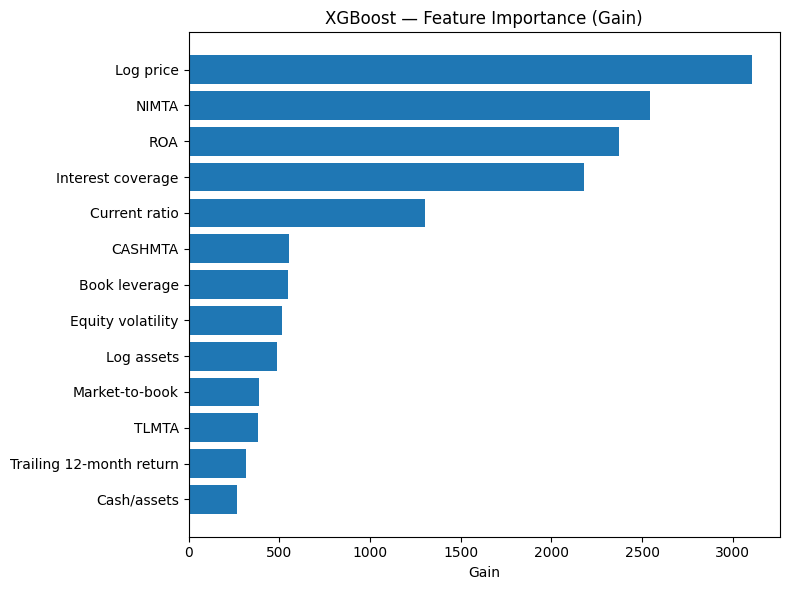

In [17]:
importance = model_xgb.get_booster().get_score(importance_type="gain")
imp_df = (
    pd.DataFrame({"feature": list(importance.keys()), "gain": list(importance.values())})
    .sort_values("gain", ascending=False)
)
imp_df["feature_label"] = imp_df["feature"].map(FEATURE_LABELS).fillna(imp_df["feature"])
print(imp_df[["feature_label", "gain"]].round(2).to_string(index=False))

imp_sorted = imp_df.sort_values("gain")
plt.figure(figsize=(8, 6))
plt.barh(imp_sorted["feature_label"], imp_sorted["gain"])
plt.xlabel("Gain")
plt.title("XGBoost — Feature Importance (Gain)")
plt.tight_layout()
plt.savefig(FIG_DIR / "xgb_feature_importance.png", dpi=150)
plt.show()

## 9. Confusion matrices at the KS-optimal threshold

Calibrated model; per-window threshold maximizing KS separation.

In [18]:
def confusion_at_ks_threshold(model, test_df, label):
    y = test_df[outcome]
    pred = model.predict_proba(test_df[features])[:, 1]
    thresholds = np.sort(np.unique(pred))
    ks_scores = [
        ((pred >= t) & (y == 1)).sum() / (y == 1).sum()
        - ((pred >= t) & (y == 0)).sum() / (y == 0).sum()
        for t in thresholds
    ]
    best_t = thresholds[int(np.argmax(ks_scores))]
    cm = confusion_matrix(y, (pred >= best_t).astype(int))
    print(f"\n-- {label}  (threshold = {best_t:.4f}) --")
    print("                 Predicted Safe  Predicted Default")
    print(f"Actual Safe      {cm[0, 0]:>14,}  {cm[0, 1]:>17,}")
    print(f"Actual Default   {cm[1, 0]:>14,}  {cm[1, 1]:>17,}")
    print(classification_report(y, (pred >= best_t).astype(int), target_names=["Safe", "Default"]))
 
 
for label, test_df in test_sets.items():
    confusion_at_ks_threshold(calibrated, test_df, label)


-- test1  (threshold = 0.0071) --
                 Predicted Safe  Predicted Default
Actual Safe              14,970              2,131
Actual Default               28                169
              precision    recall  f1-score   support

        Safe       1.00      0.88      0.93     17101
     Default       0.07      0.86      0.14       197

    accuracy                           0.88     17298
   macro avg       0.54      0.87      0.53     17298
weighted avg       0.99      0.88      0.92     17298


-- test2  (threshold = 0.0045) --
                 Predicted Safe  Predicted Default
Actual Safe              13,368              1,986
Actual Default               17                104
              precision    recall  f1-score   support

        Safe       1.00      0.87      0.93     15354
     Default       0.05      0.86      0.09       121

    accuracy                           0.87     15475
   macro avg       0.52      0.87      0.51     15475
weighted avg       0.99  